In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import deque
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.datasets import fetch_lfw_people
import os
import pickle

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'font.size': 12,
    'figure.dpi': 100,
})

Загружаем датасет LFW
Изображений: 3595
Размер патча: 62x47
Отфильтровано 2059 изображений
Мужчин 1861, Женщин 198


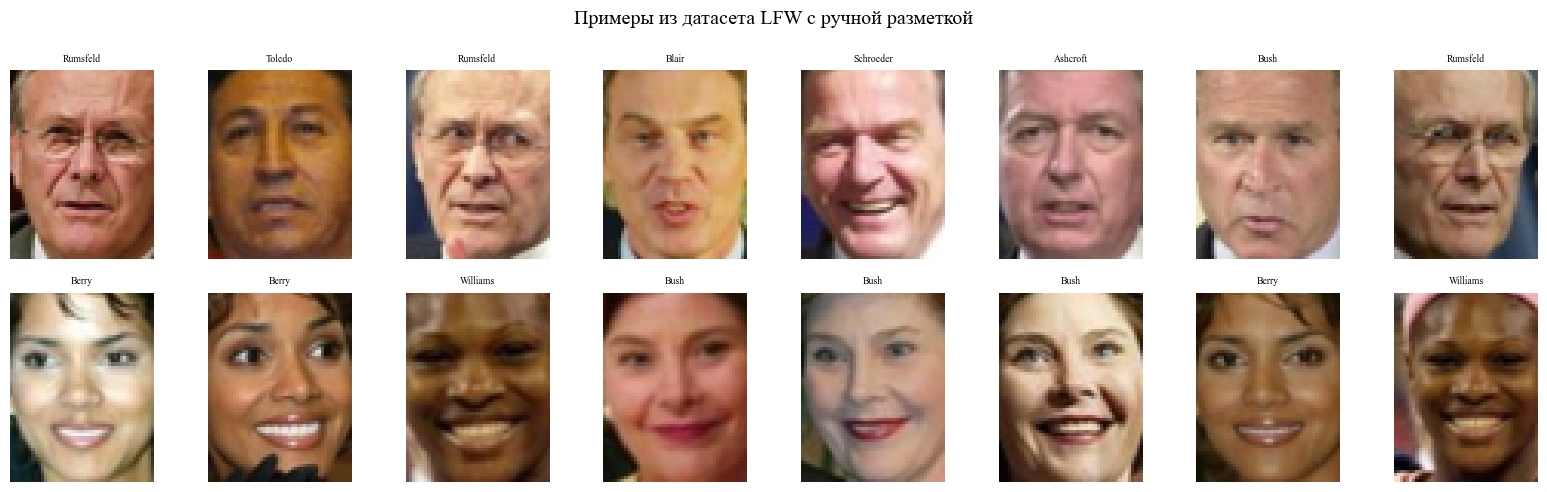

In [2]:
print('Загружаем датасет LFW')
lfw = fetch_lfw_people(min_faces_per_person=15, resize=0.5, color=True)
print(f'Изображений: {lfw.images.shape[0]}')
print(f'Размер патча: {lfw.images.shape[1]}x{lfw.images.shape[2]}')

GENDER_LABELS = {
    'Ariel Sharon': 0, 'Colin Powell': 0, 'Donald Rumsfeld': 0,
    'George W Bush': 0, 'Gerhard Schroeder': 0, 'Hugo Chavez': 0,
    'Tony Blair': 0, 'Junichiro Koizumi': 0, 'Jean Chretien': 0,
    'John Ashcroft': 0, 'Vladmir Putin': 0, 'Hamid Karzai': 0,
    'Luiz Inacio Lula da Silva': 0, 'Jacques Chirac': 0, 'Jiang Zemin': 0,
    'Vicente Fox': 0, 'Silvio Berlusconi': 0, 'Alejandro Toledo': 0,
    'John Snow': 0, 'Arnold Schwarzenegger': 0,
    'Lleyton Hewitt': 0, 'Andre Agassi': 0, 'Tiger Woods': 0,
    'Jennifer Aniston': 1, 'Halle Berry': 1, 'Laura Bush': 1,
    'Serena Williams': 1, 'Winona Ryder': 1,
    'Gloria Macapagal Arroyo': 1, 'Condoleezza Rice': 1,
}

valid_indices = []
gender_labels = []
for i, tid in enumerate(lfw.target):
    name = lfw.target_names[tid]
    if name in GENDER_LABELS:
        valid_indices.append(i)
        gender_labels.append(GENDER_LABELS[name])

images_valid = lfw.images[valid_indices]
y_gender = np.array(gender_labels)

print(f'Отфильтровано {len(images_valid)} изображений')
print(f'Мужчин {(y_gender==0).sum()}, Женщин {(y_gender==1).sum()}')

f, axes = plt.subplots(2, 8, figsize=(16, 5))
for row, gender in enumerate([0, 1]):
    idxs = np.where(y_gender == gender)[0][:8]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(images_valid[idx])
        axes[row, col].axis('off')
        name = lfw.target_names[lfw.target[valid_indices[idx]]]
        axes[row, col].set_title(name.split()[-1], fontsize=7)
axes[0,0].set_ylabel('Мужчины'); axes[1,0].set_ylabel('Женщины')
plt.suptitle('Примеры из датасета LFW с ручной разметкой')
plt.tight_layout(); plt.show()

In [3]:
def to_gray_manual(image_float):
    if image_float.ndim == 3:
        return (0.299*image_float[:,:,0] + 0.587*image_float[:,:,1] + 0.114*image_float[:,:,2]) * 255.0
    return image_float * 255.0

def bilinear_resize(image, target_h, target_w):
    orig_h, orig_w = image.shape[:2]
    if target_h == orig_h and target_w == orig_w:
        return image
    
    sy, sx = orig_h / target_h, orig_w / target_w
    gy, gx = np.mgrid[0:target_h, 0:target_w]
    
    src_y = gy * sy
    src_x = gx * sx
    y0, x0 = np.floor(src_y).astype(int), np.floor(src_x).astype(int)
    y1 = np.minimum(y0 + 1, orig_h - 1)
    x1 = np.minimum(x0 + 1, orig_w - 1)
    
    dy, dx = src_y - y0, src_x - x0
    w1 = (1-dy) * (1-dx)
    w2 = dy * (1-dx)
    w3 = (1-dy) * dx
    w4 = dy * dx
    
    if image.ndim == 2:
        out = image[y0, x0]*w1 + image[y1, x0]*w2 + image[y0, x1]*w3 + image[y1, x1]*w4
    else:
        out = np.stack([
            image[y0, x0]*w1 + image[y1, x0]*w2 + image[y0, x1]*w3 + image[y1, x1]*w4
            for i in range(3)], axis=-1)
    return np.clip(out, 0, 255).astype(np.uint8)

In [4]:
def compute_lbp_manual(gray_uint8):
    p = np.pad(gray_uint8, 1, mode='edge')
    
    tl = p[:-2, :-2]; t = p[:-2, 1:-1]; tr = p[:-2, 2:]
    l  = p[1:-1, :-2];                 r = p[1:-1, 2:]
    bl = p[2:, :-2];   b = p[2:, 1:-1];  br = p[2:, 2:]
    c  = p[1:-1, 1:-1]
    
    lbp = ((t >= c) << 7) | ((tr >= c) << 6) | ((r >= c) << 5) | \
          ((br >= c) << 4) | ((b >= c) << 3) | ((bl >= c) << 2) | \
          ((l >= c) << 1) | ((tl >= c) << 0)
          
    hist, _ = np.histogram(lbp, bins=256, range=(0, 256))
    return (hist / (hist.sum() + 1e-6)).flatten()

test_gray = to_gray_manual(images_valid[0]).astype(np.uint8)
test_gray_resized = bilinear_resize(test_gray, 48, 48)
desc = compute_lbp_manual(test_gray_resized)
print(f'Размер LBP-вектора: {desc.shape[0]}')

Размер LBP-вектора: 256


In [5]:
TARGET_SIZE = (48, 48)
print('Вычисляем LBP-дескрипторы')
X_faces = []
for i, img in enumerate(images_valid):
    gray = to_gray_manual(img).astype(np.uint8)
    gray_res = bilinear_resize(gray, TARGET_SIZE[1], TARGET_SIZE[0])
    X_faces.append(compute_lbp_manual(gray_res))
    if (i+1) % 200 == 0:
        print(f'  Обработано: {i+1}/{len(images_valid)}')

X_faces = np.array(X_faces)
print(f'Матрица признаков лиц {X_faces.shape}')

Вычисляем LBP-дескрипторы
  Обработано: 200/2059
  Обработано: 400/2059
  Обработано: 600/2059
  Обработано: 800/2059
  Обработано: 1000/2059
  Обработано: 1200/2059
  Обработано: 1400/2059
  Обработано: 1600/2059
  Обработано: 1800/2059
  Обработано: 2000/2059
Матрица признаков лиц (2059, 256)


Генерируем синтетические негативы из LFW


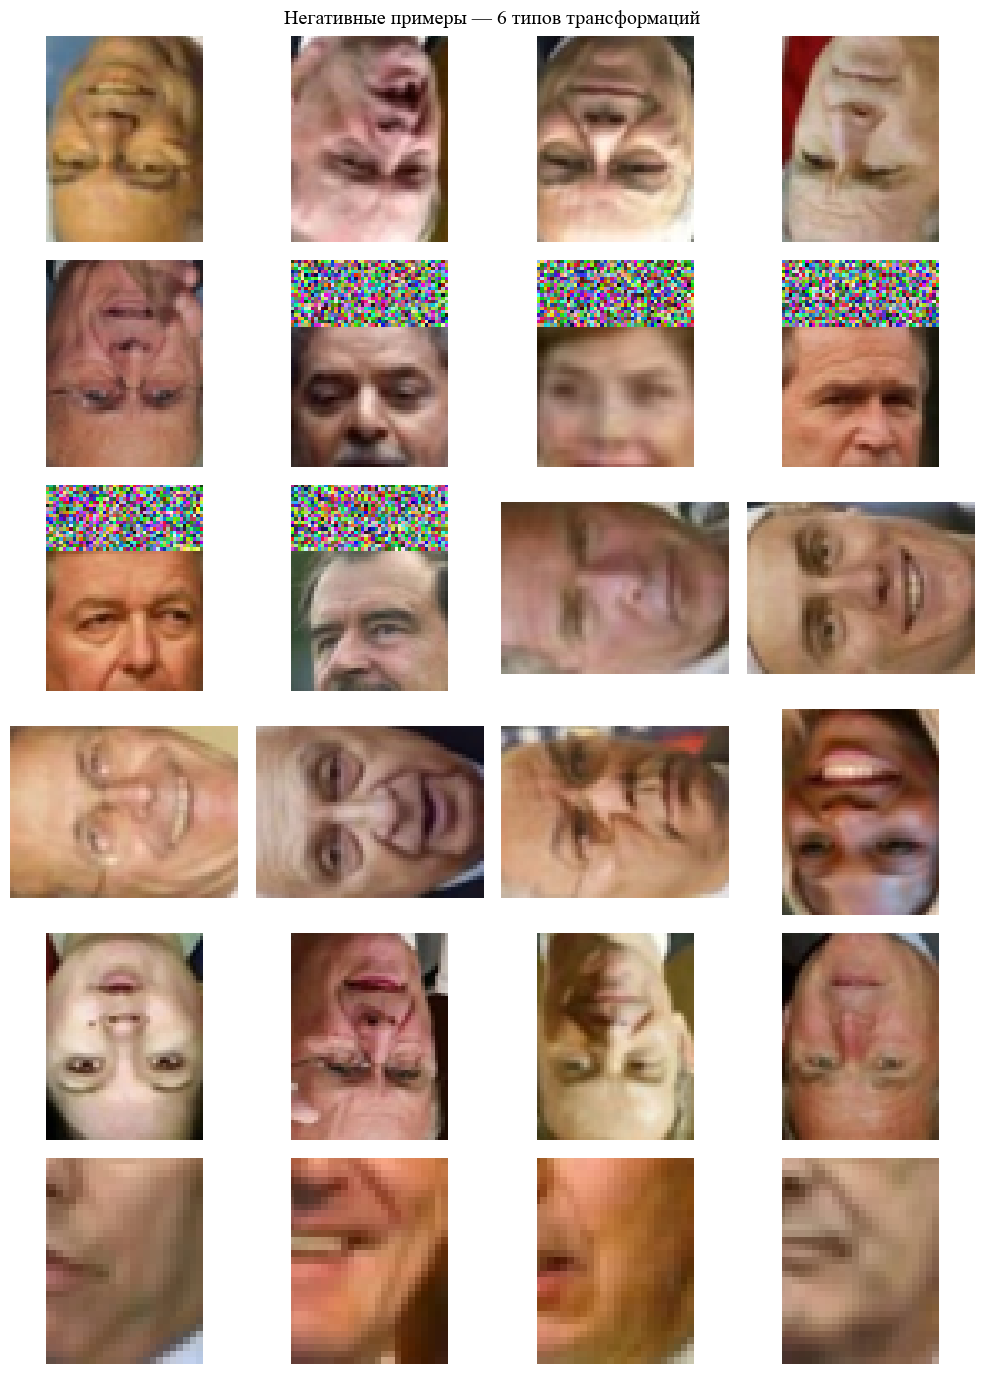

Вычисляем LBP для негативов
  Обработано негативов: 500/2059
  Обработано негативов: 1000/2059
  Обработано негативов: 1500/2059
  Обработано негативов: 2000/2059
Всего для детектора: (4118, 256) (лица: 2059, не-лица: 2059)


In [6]:
print('Генерируем синтетические негативы из LFW')
np.random.seed(42)
N_NEG = len(images_valid)
negatives = []

def make_negatives(all_imgs, n_total):
    per_type = n_total // 6 + 1
    neg_list = []
    idx = np.random.permutation(len(all_imgs))
    
    for i in range(per_type):
        patch = all_imgs[idx[i % n_imgs]].copy()
        # Вертикальный флип
        neg_list.append(np.flipud(patch))
    for i in range(per_type):
        patch = all_imgs[idx[(i+per_type)%n_imgs]].copy()
        # Сдвиг + шум сверху
        patch_shifted = np.roll(patch, 20, axis=0)
        patch_shifted[:20] = np.random.rand(20, patch.shape[1], 3).astype(np.float32)
        neg_list.append(patch_shifted)
    for i in range(per_type):
        patch = all_imgs[idx[(i+2*per_type)%n_imgs]].copy()
        # Транспонирование 90 град
        neg_list.append(np.transpose(patch, (1, 0, 2)))
    for i in range(per_type):
        patch = all_imgs[idx[(i+3*per_type)%n_imgs]].copy()
        # Переворот 180
        neg_list.append(np.flipud(np.fliplr(patch)))
    for i in range(per_type):
        patch = all_imgs[idx[(i+4*per_type)%n_imgs]].copy()
        # Угловой кроп (растягиваем и берём угол)
        big = np.kron(patch, np.ones((2, 2, 1)))
        neg_list.append(big[-62:, -47:, :])
    for i in range(per_type):
        # Чистый шум
        neg_list.append(np.random.rand(62, 47, 3).astype(np.float32))
        
    return neg_list[:n_total]

n_imgs = len(images_valid)
neg_patches = make_negatives(images_valid, N_NEG)



per_type = N_NEG // 6
labels_types = ['вертик. флип', 'сдвиг вниз', 'поворот 90°', 'поворот 180°', 'угловой кроп', 'шум']

f, axes = plt.subplots(6, 4, figsize=(10, 14))
for t in range(6):
    for j in range(4):
        # Индекс патча: тип t, пример j внутри типа
        idx = t * per_type + j
        axes[t, j].imshow(np.clip(neg_patches[idx], 0, 1))
        axes[t, j].axis('off')
    axes[t, 0].set_ylabel(labels_types[t], fontsize=9)

plt.suptitle('Негативные примеры — 6 типов трансформаций')
plt.tight_layout()
plt.show()



print('Вычисляем LBP для негативов')
X_neg = []
for i, patch in enumerate(neg_patches):
    gray = to_gray_manual(patch).astype(np.uint8)
    gray_res = bilinear_resize(gray, TARGET_SIZE[1], TARGET_SIZE[0])
    X_neg.append(compute_lbp_manual(gray_res))
    if (i+1) % 500 == 0:
        print(f'  Обработано негативов: {i+1}/{N_NEG}')

X_neg = np.array(X_neg)
y_neg = np.full(N_NEG, -1)
X_detect = np.vstack([X_faces, X_neg])
y_detect = np.concatenate([np.ones(len(X_faces), dtype=int), y_neg])

print(f'Всего для детектора: {X_detect.shape} (лица: {(y_detect==1).sum()}, не-лица: {(y_detect==-1).sum()})')

In [7]:
print('Обучаем детектор лицо / не-лицо')
X_tr, X_te, y_tr, y_te = train_test_split(
    X_detect, y_detect, test_size=0.2, random_state=42, stratify=y_detect
)

detector_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0, max_iter=3000))
])
detector_pipe.fit(X_tr, y_tr)
y_pred_det = detector_pipe.predict(X_te)
print(f'Точность детектора: {accuracy_score(y_te, y_pred_det):.3f}')
print(classification_report(y_te, y_pred_det, target_names=['не-лицо', 'лицо']))

print('\nОбучаем классификатор пола')
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_faces, y_gender, test_size=0.2, random_state=42, stratify=y_gender
)

gender_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0, max_iter=3000))
])
gender_pipe.fit(X_tr_g, y_tr_g)
y_pred_g = gender_pipe.predict(X_te_g)
print(f'Точность классификатора пола: {accuracy_score(y_te_g, y_pred_g):.3f}')
print(classification_report(y_te_g, y_pred_g, target_names=['мужчина', 'женщина']))

with open('lbp_detector.pkl', 'wb') as f: pickle.dump(detector_pipe, f)
with open('lbp_gender.pkl', 'wb') as f: pickle.dump(gender_pipe, f)

Обучаем детектор лицо / не-лицо
Точность детектора: 0.938
              precision    recall  f1-score   support

     не-лицо       0.94      0.93      0.94       412
        лицо       0.93      0.94      0.94       412

    accuracy                           0.94       824
   macro avg       0.94      0.94      0.94       824
weighted avg       0.94      0.94      0.94       824


Обучаем классификатор пола
Точность классификатора пола: 0.908
              precision    recall  f1-score   support

     мужчина       0.96      0.94      0.95       372
     женщина       0.52      0.62      0.57        40

    accuracy                           0.91       412
   macro avg       0.74      0.78      0.76       412
weighted avg       0.92      0.91      0.91       412



In [8]:
def image_pyramid_manual(image_uint8, scale=0.85, min_size=64):
    img = image_uint8.copy()
    factor = 1.0
    while True:
        yield img, factor
        h, w = img.shape[:2]
        new_h, new_w = int(h * scale), int(w * scale)
        if new_h < min_size or new_w < min_size:
            break
        img = bilinear_resize(img, new_h, new_w)
        factor *= scale

def sliding_window_manual(image_uint8, win_h, win_w, step=16):
    h, w = image_uint8.shape[:2]
    for r in range(0, h - win_h + 1, step):
        for c in range(0, w - win_w + 1, step):
            yield r, c, image_uint8[r:r+win_h, c:c+win_w]

def iou_manual(boxA, boxB):
    r0 = max(boxA[0], boxB[0]); c0 = max(boxA[1], boxB[1])
    r1 = min(boxA[2], boxB[2]); c1 = min(boxA[3], boxB[3])
    inter = max(0, r1-r0) * max(0, c1-c0)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def nms_manual(detections, iou_thresh=0.3):
    if not detections: return []
    detections = sorted(detections, key=lambda x: x[0], reverse=True)
    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)
        detections = [d for d in detections if iou_manual(best[1:], d[1:]) < iou_thresh]
    return kept

In [9]:
def detect_and_classify_lbp(image_uint8, detector, gender_clf,
                        win_h, win_w, step=16, scale=0.85,
                        det_threshold=0.5, iou_thresh=0.3):
    detections = []
    for img_scaled, factor in image_pyramid_manual(image_uint8, scale=scale):
        for r, c, patch in sliding_window_manual(img_scaled, win_h, win_w, step):
            gray = to_gray_manual(patch).astype(np.uint8)
            gray_res = bilinear_resize(gray, win_w, win_h)
            desc = compute_lbp_manual(gray_res).reshape(1, -1)
            
            score = detector.decision_function(desc)[0]
            if score > det_threshold:
                r0 = int(r / factor); c0 = int(c / factor)
                r1 = int((r+win_h) / factor); c1 = int((c+win_w) / factor)
                detections.append((score, r0, c0, r1, c1))
                
    detections = nms_manual(detections, iou_thresh)
    
    results = []
    for score, r0, c0, r1, c1 in detections:
        crop = image_uint8[r0:r1, c0:c1]
        if crop.size == 0: continue
        gray = to_gray_manual(crop).astype(np.uint8)
        gray_res = bilinear_resize(gray, win_w, win_h)
        desc = compute_lbp_manual(gray_res).reshape(1, -1)
        gender = gender_clf.predict(desc)[0]
        results.append((r0, c0, r1, c1, gender))
    return results

WIN_H, WIN_W = TARGET_SIZE[1], TARGET_SIZE[0]
print(f'Размер окна детектора {WIN_H}×{WIN_W} пикселей')

Размер окна детектора 48×48 пикселей


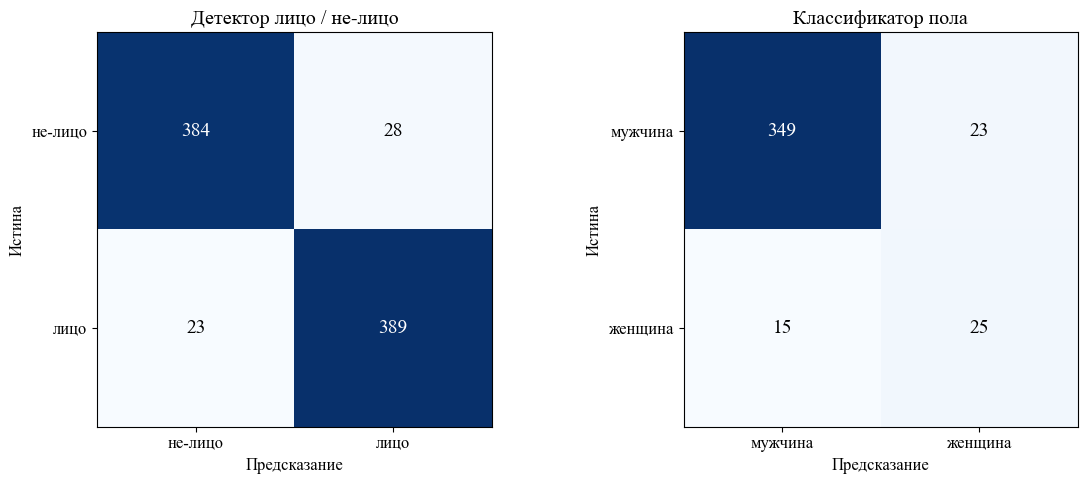

Точность детектора:           0.938
Точность классификатора пола: 0.908


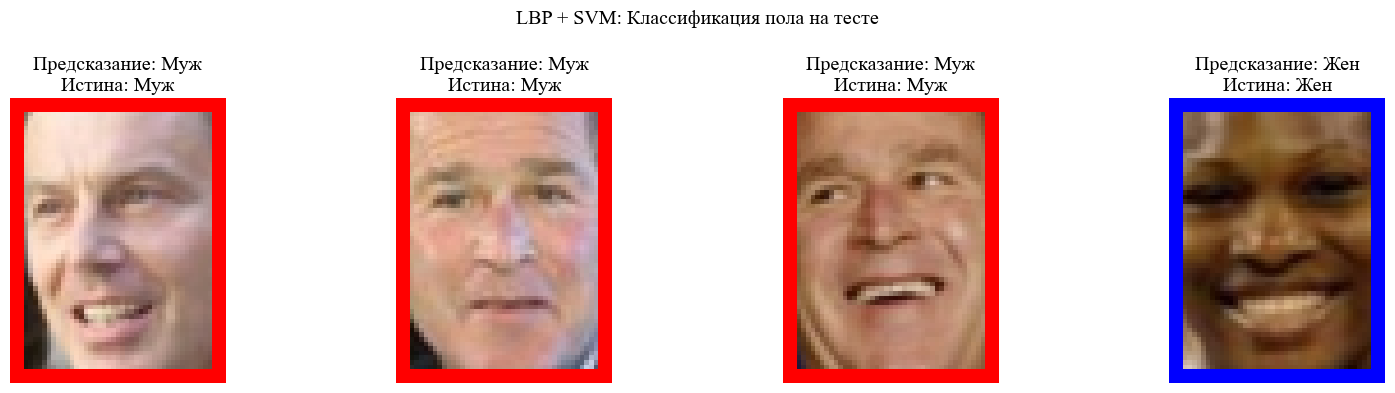

In [10]:
y_pred_det = detector_pipe.predict(X_te)
cm_det = confusion_matrix(y_te, y_pred_det, labels=[-1, 1])
y_pred_gen = gender_pipe.predict(X_te_g)
cm_gen = confusion_matrix(y_te_g, y_pred_gen, labels=[0, 1])

f, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title, labels in [
    (axes[0], cm_det, 'Детектор лицо / не-лицо', ['не-лицо', 'лицо']),
    (axes[1], cm_gen, 'Классификатор пола', ['мужчина', 'женщина'])
]:
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title); ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_ylabel('Истина'); ax.set_xlabel('Предсказание')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
plt.tight_layout(); plt.show()

print(f'Точность детектора:           {accuracy_score(y_te, y_pred_det):.3f}')
print(f'Точность классификатора пола: {accuracy_score(y_te_g, y_pred_gen):.3f}')

test_imgs_idx = np.random.choice(len(X_te_g), 4, replace=False)
f, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, idx in enumerate(test_imgs_idx):
    orig_idx = valid_indices[idx]
    img = (lfw.images[orig_idx] * 255).astype(np.uint8)
    pred = gender_pipe.predict(X_faces[idx].reshape(1, -1))[0]
    true = y_gender[idx]
    color = [255, 0, 0] if pred == 0 else [0, 0, 255]
    img_vis = img.copy()
    img_vis[:3, :] = img_vis[-3:, :] = img_vis[:, :3] = img_vis[:, -3:] = color
    axes[i].imshow(img_vis)
    axes[i].set_title(f'Предсказание: {"Муж" if pred==0 else "Жен"}\nИстина: {"Муж" if true==0 else "Жен"}')
    axes[i].axis('off')
plt.suptitle('LBP + SVM: Классификация пола на тесте')
plt.tight_layout(); plt.show()